# SETUP & LOAD MASTER DATASET

In [92]:
# ============================================================
# CELL 1: SETUP & LOAD MASTER DATASET
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load master dataset
df = pd.read_csv(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\data\processed\master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"📊 Master Dataset: {len(df)} baris")
print(f"Periode: {df['date'].min()} → {df['date'].max()}")
print(f"\nKolom: {list(df.columns)}")

📊 Master Dataset: 1407 baris
Periode: 2019-03-14 00:00:00 → 2024-12-30 00:00:00

Kolom: ['date', 'open', 'high', 'low', 'close', 'volume', 'daily_return', 'log_return', 'volatility_20d', 'ma_50', 'avg_sentiment', 'std_sentiment', 'news_count', 'positive_ratio', 'sentiment_lag_1', 'sentiment_lag_2', 'sentiment_lag_3', 'sentiment_ma_7', 'sentiment_ma_14', 'sentiment_change']


# STATISTIK DESKRIPTIF

In [93]:
# ============================================================
# CELL 2: STATISTIK DESKRIPTIF
# ============================================================

print("=" * 60)
print("📋 STATISTIK DESKRIPTIF IHSG")
print("=" * 60)
print(df[['close', 'daily_return', 'log_return', 'volatility_20d', 'volume']].describe())

print("\n" + "=" * 60)
print("📋 STATISTIK DESKRIPTIF SENTIMEN")
print("=" * 60)
print(df[['avg_sentiment', 'std_sentiment', 'news_count', 'positive_ratio']].describe())

print("\n" + "=" * 60)
print("📋 KORELASI AWAL (Pearson)")
print("=" * 60)
corr_cols = ['daily_return', 'log_return', 'avg_sentiment', 'news_count', 'volatility_20d']
print(df[corr_cols].corr())

📋 STATISTIK DESKRIPTIF IHSG
             close  daily_return   log_return  volatility_20d        volume
count  1407.000000   1407.000000  1407.000000     1407.000000  1.407000e+03
mean   6481.755461      0.000124     0.000074        0.137019  1.533515e+08
std     736.851542      0.009956     0.009956        0.077056  6.506268e+07
min    3937.632080     -0.065787    -0.068051        0.049735  0.000000e+00
25%    6109.498047     -0.004759    -0.004770        0.097172  1.136472e+08
50%    6651.904785      0.000465     0.000465        0.118627  1.520421e+08
75%    7016.449707      0.005284     0.005271        0.151811  1.921698e+08
max    7905.390137      0.101907     0.097042        0.671505  6.150719e+08

📋 STATISTIK DESKRIPTIF SENTIMEN
       avg_sentiment  std_sentiment   news_count  positive_ratio
count    1407.000000    1407.000000  1407.000000     1407.000000
mean        0.003741       0.007055     1.176972        0.020528
std         0.059018       0.042503     1.413945        0.12

# TIME SERIES - IHSG & SENTIMEN

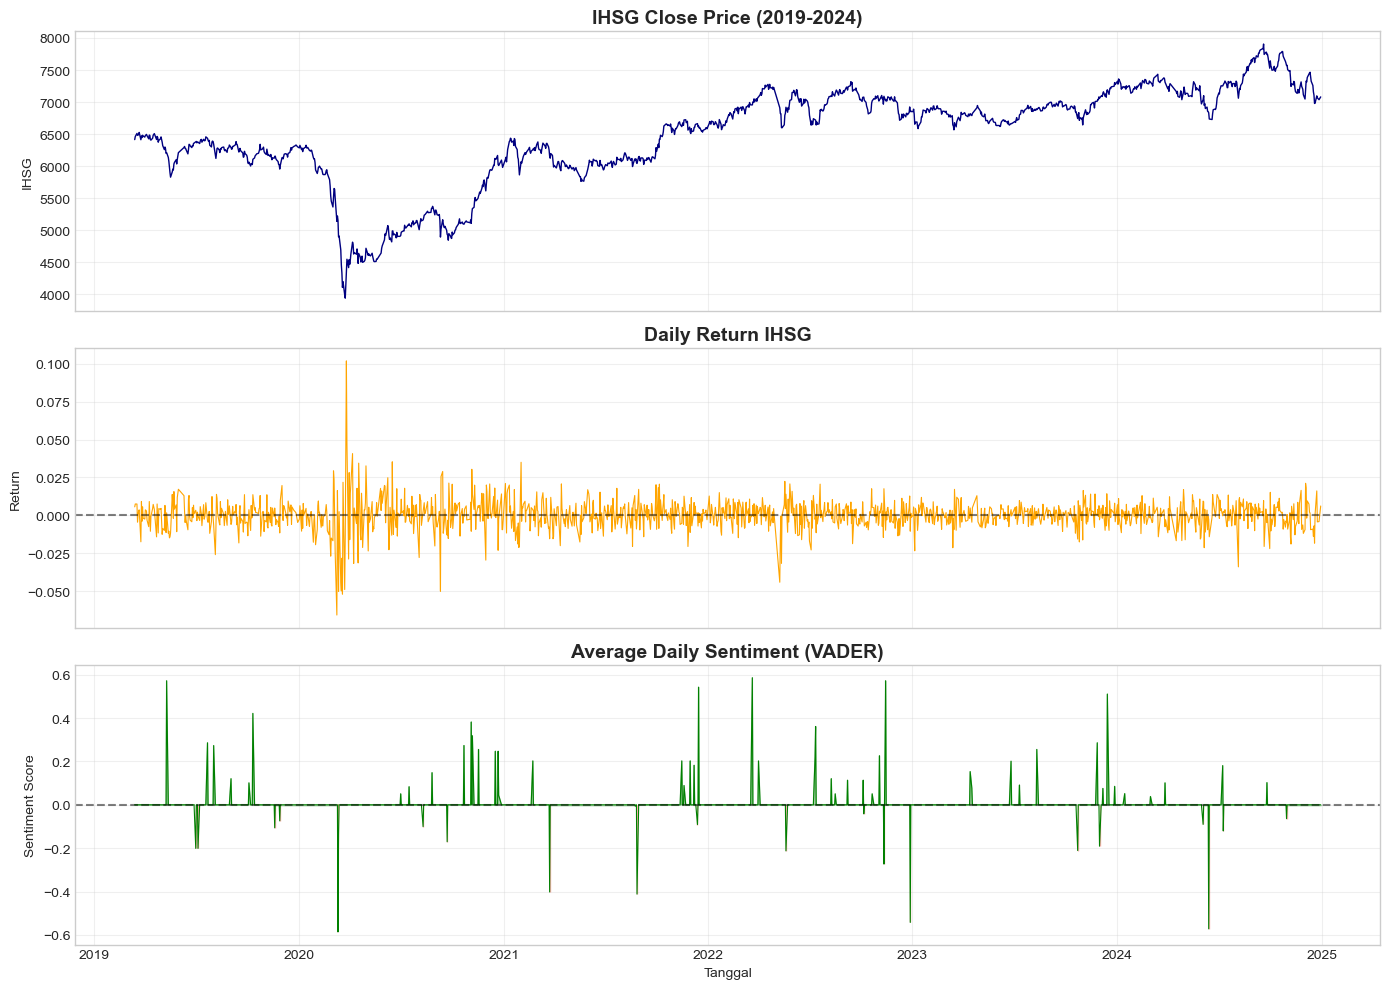

💾 Disimpan: reports/figures/time_series_overview.png


In [94]:
# ============================================================
# CELL 3: TIME SERIES - IHSG & SENTIMEN
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: IHSG Close Price
axes[0].plot(df['date'], df['close'], color='navy', linewidth=1)
axes[0].set_title('IHSG Close Price (2019-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('IHSG')
axes[0].grid(True, alpha=0.3)

# Plot 2: Daily Return
axes[1].plot(df['date'], df['daily_return'], color='orange', linewidth=0.8)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Daily Return IHSG', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

# Plot 3: Average Sentiment
axes[2].plot(df['date'], df['avg_sentiment'], color='green', linewidth=0.8)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].fill_between(df['date'], df['avg_sentiment'], 0, 
                     where=(df['avg_sentiment'] >= 0), color='green', alpha=0.3)
axes[2].fill_between(df['date'], df['avg_sentiment'], 0, 
                     where=(df['avg_sentiment'] < 0), color='red', alpha=0.3)
axes[2].set_title('Average Daily Sentiment (VADER)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Sentiment Score')
axes[2].set_xlabel('Tanggal')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\time_series_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/time_series_overview.png")

# DUAL AXIS - IHSG vs SENTIMEN

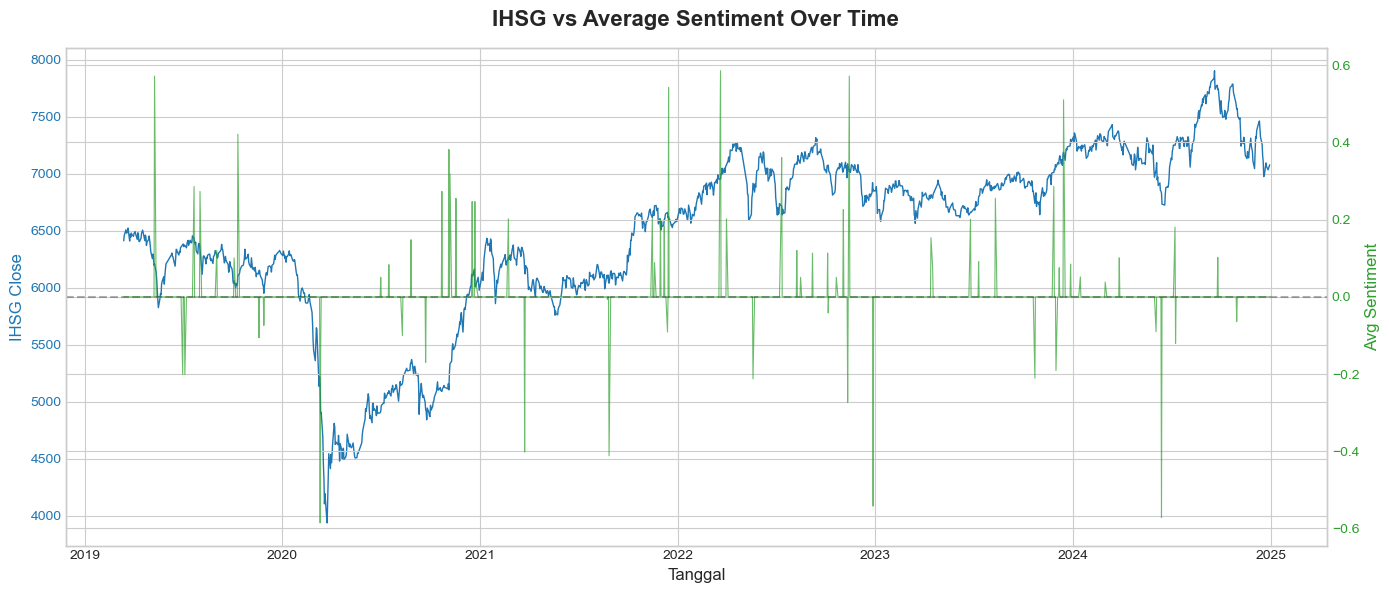

💾 Disimpan: reports/figures/eda/ihsg_vs_sentiment_dual.png


In [95]:
# ============================================================
# CELL 4: DUAL AXIS - IHSG vs SENTIMEN
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Tanggal', fontsize=12)
ax1.set_ylabel('IHSG Close', color=color1, fontsize=12)
ax1.plot(df['date'], df['close'], color=color1, linewidth=1, label='IHSG')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Avg Sentiment', color=color2, fontsize=12)
ax2.plot(df['date'], df['avg_sentiment'], color=color2, linewidth=0.8, alpha=0.7, label='Sentiment')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)

fig.suptitle('IHSG vs Average Sentiment Over Time', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\ihsg_vs_sentiment_dual.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/eda/ihsg_vs_sentiment_dual.png")

# DISTRIBUSI SENTIMEN

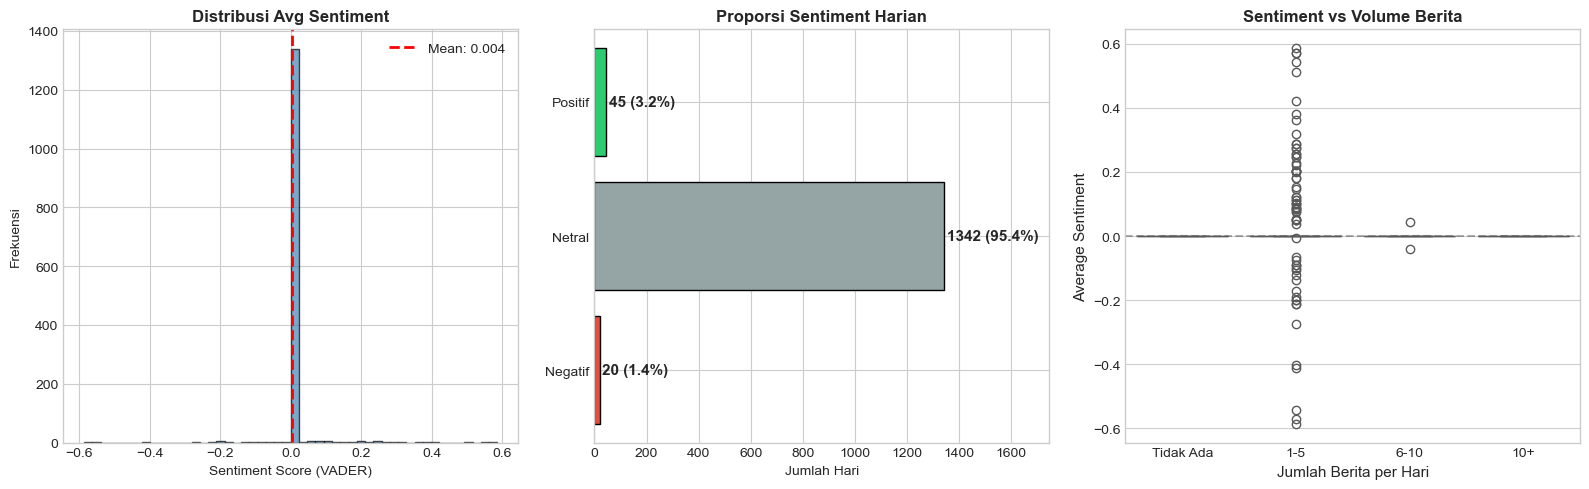

💾 Disimpan: reports/figures/sentiment_distribution.png


In [96]:
# ============================================================
# CELL 5: DISTRIBUSI SENTIMEN (FIXED - ANTI TABRAK)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Histogram ---
axes[0].hist(df['avg_sentiment'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Avg Sentiment', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Sentiment Score (VADER)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['avg_sentiment'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {df["avg_sentiment"].mean():.3f}')
axes[0].legend(loc='upper right')

# --- Plot 2: HORIZONTAL BAR CHART ---
sentiment_category = pd.cut(df['avg_sentiment'], bins=[-1, -0.05, 0.05, 1], labels=['Negatif', 'Netral', 'Positif'])
counts = sentiment_category.value_counts().sort_index()

colors = ['#e74c3c', '#95a5a6', '#2ecc71']  # Merah, Abu, Hijau
bars = axes[1].barh(counts.index, counts.values, color=colors, edgecolor='black')

# Tambah label persentase di ujung bar
total = counts.sum()
for bar, val in zip(bars, counts.values):
    pct = (val / total) * 100
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                 f'{val} ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

axes[1].set_title('Proporsi Sentiment Harian', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Jumlah Hari')
axes[1].set_xlim(0, max(counts.values) * 1.3)  # Kasih ruang untuk label

# --- Plot 3: BOX PLOT ---
# Rename kategori agar lebih jelas
df['news_volume_label'] = df['news_count'].apply(
    lambda x: 'Tidak Ada' if x == 0 else ('1-5' if x <= 5 else ('6-10' if x <= 10 else '10+'))
)

# Urutan kategori
order = ['Tidak Ada', '1-5', '6-10', '10+']
sns.boxplot(data=df, x='news_volume_label', y='avg_sentiment', 
            order=order, ax=axes[2], palette='Set2')

axes[2].set_title('Sentiment vs Volume Berita', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Jumlah Berita per Hari', fontsize=11)
axes[2].set_ylabel('Average Sentiment', fontsize=11)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\sentiment_distribution_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/sentiment_distribution.png")

# HEATMAP KORELASI

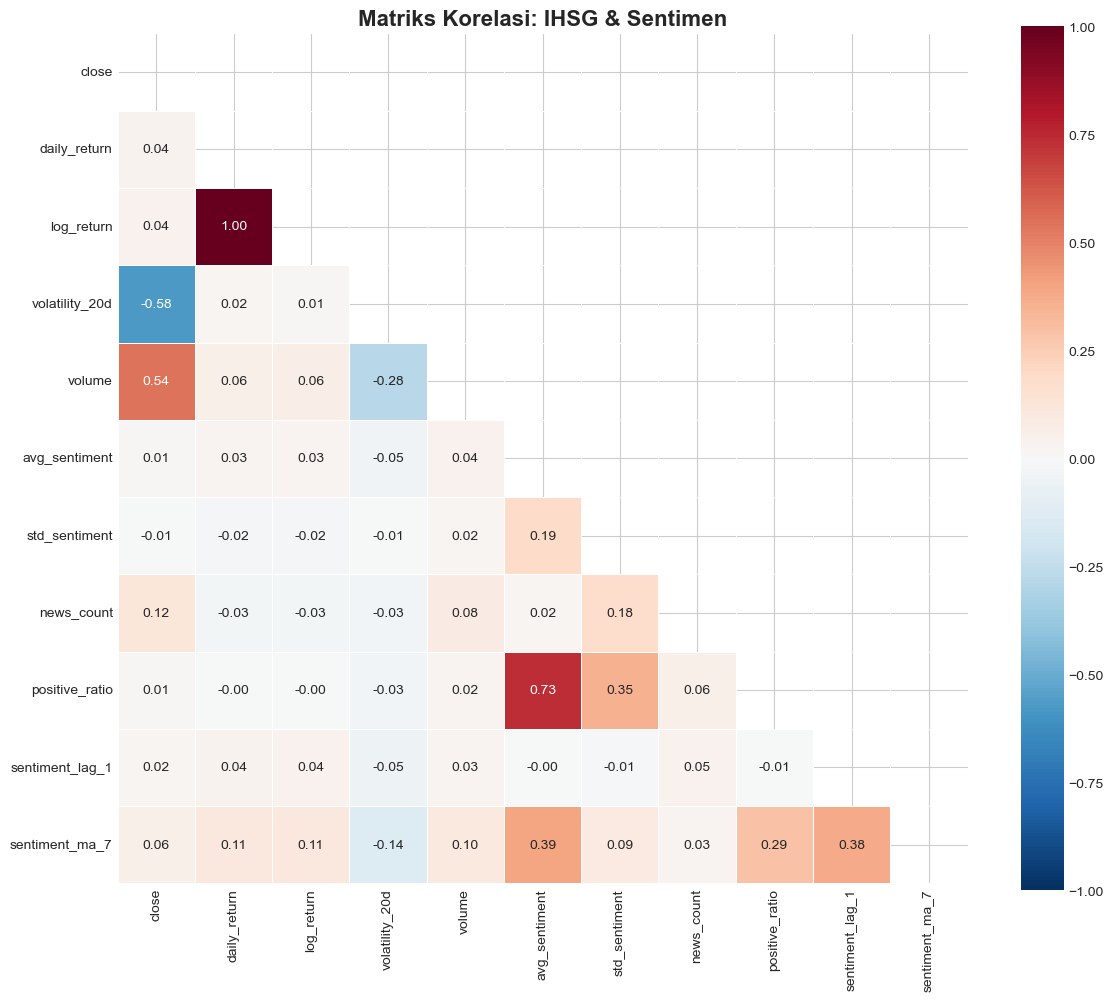

💾 Disimpan: reports/figures/correlation_heatmap.png


In [97]:
# ============================================================
# CELL 6: HEATMAP KORELASI
# ============================================================

# Pilih variabel numerik
corr_vars = ['close', 'daily_return', 'log_return', 'volatility_20d', 
             'volume', 'avg_sentiment', 'std_sentiment', 'news_count', 
             'positive_ratio', 'sentiment_lag_1', 'sentiment_ma_7']

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriks Korelasi: IHSG & Sentimen', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/correlation_heatmap.png")

# SCATTER PLOT - SENTIMEN vs RETURN

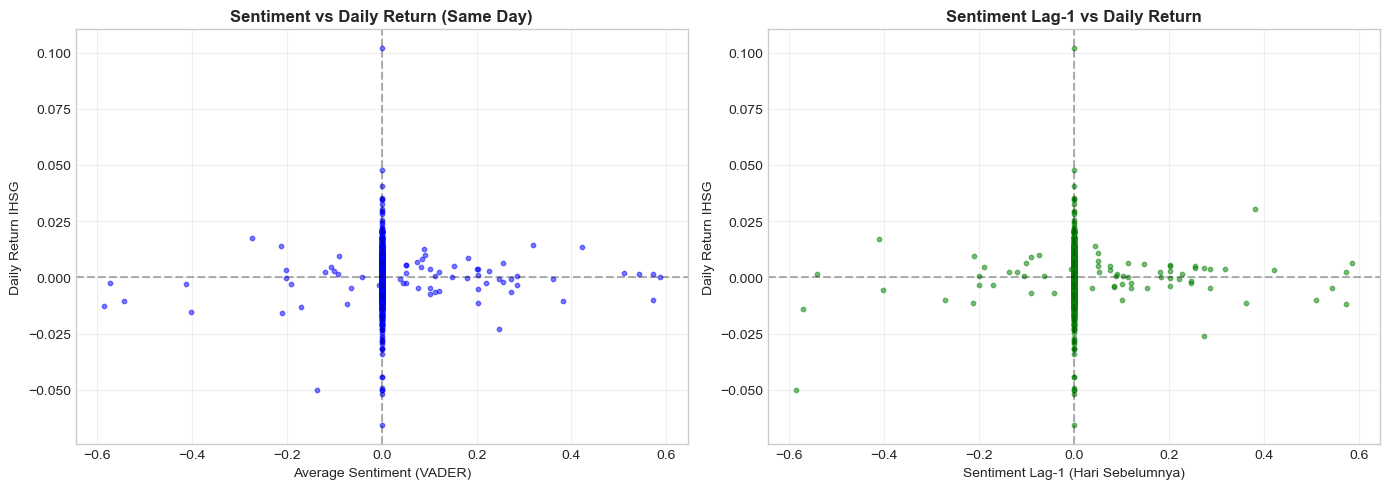

💾 Disimpan: reports/figures/scatter_sentiment_return.png


In [98]:
# ============================================================
# CELL 7: SCATTER PLOT - SENTIMEN vs RETURN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment vs Daily Return (same day)
axes[0].scatter(df['avg_sentiment'], df['daily_return'], alpha=0.5, s=10, color='blue')
axes[0].set_xlabel('Average Sentiment (VADER)')
axes[0].set_ylabel('Daily Return IHSG')
axes[0].set_title('Sentiment vs Daily Return (Same Day)', fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

# Sentiment Lag-1 vs Daily Return (prediksi)
axes[1].scatter(df['sentiment_lag_1'], df['daily_return'], alpha=0.5, s=10, color='green')
axes[1].set_xlabel('Sentiment Lag-1 (Hari Sebelumnya)')
axes[1].set_ylabel('Daily Return IHSG')
axes[1].set_title('Sentiment Lag-1 vs Daily Return', fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\scatter_sentiment_return.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/scatter_sentiment_return.png")

# ANALISIS OUTLIER

📌 Outlier Return (|Z| > 3): 20 hari

Top 10 Outlier Negatif (Crash):
           date  daily_return  avg_sentiment  news_count
243  2020-03-09     -0.065787         0.0000           1
251  2020-03-19     -0.052013         0.0000           2
246  2020-03-12     -0.050126        -0.1366           2
364  2020-09-10     -0.050087         0.0000           1
249  2020-03-17     -0.049867         0.0000           1
253  2020-03-23     -0.048970         0.0000           0
248  2020-03-16     -0.044200         0.0000           0
765  2022-05-09     -0.044151         0.0000           0
1305 2024-08-05     -0.033999         0.0000           0
264  2020-04-08     -0.031797         0.0000           1

Top 10 Outlier Positif (Surge):
          date  daily_return  avg_sentiment  news_count
255 2020-03-26      0.101907            0.0           1
256 2020-03-27      0.047631            0.0           0
262 2020-04-06      0.040749            0.0           0
306 2020-06-16      0.035322            0.0    

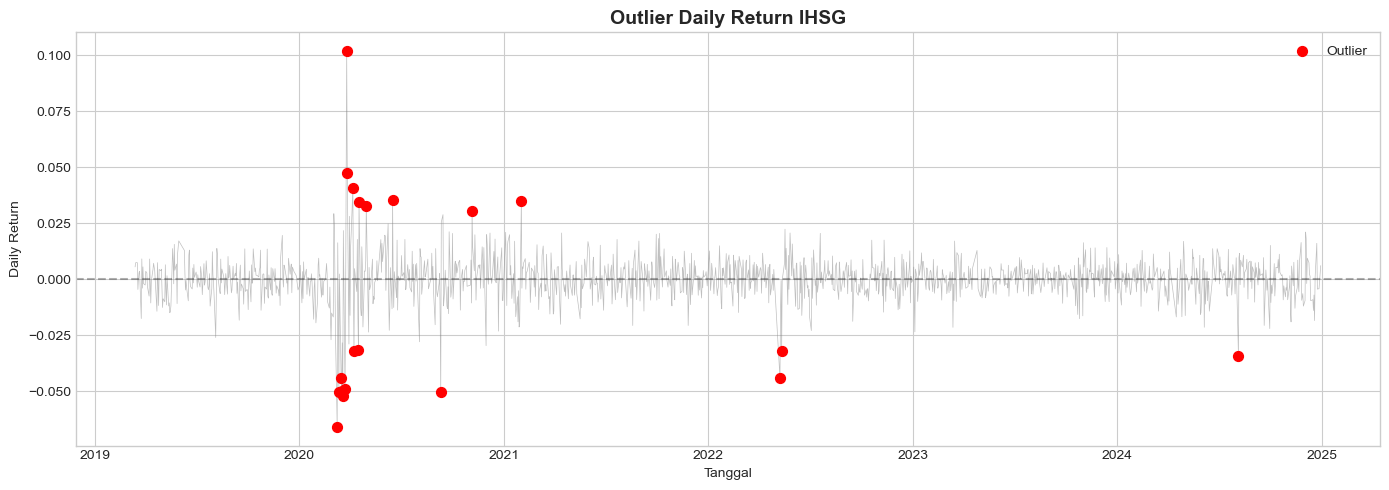

💾 Disimpan: reports/figures/outlier_analysis.png


In [99]:
# ============================================================
# CELL 8: ANALISIS OUTLIER
# ============================================================

# Identifikasi outlier return (Z-score > 3)
df['return_zscore'] = (df['daily_return'] - df['daily_return'].mean()) / df['daily_return'].std()
outliers = df[abs(df['return_zscore']) > 3]

print(f"📌 Outlier Return (|Z| > 3): {len(outliers)} hari")
print("\nTop 10 Outlier Negatif (Crash):")
print(outliers.nsmallest(10, 'daily_return')[['date', 'daily_return', 'avg_sentiment', 'news_count']])

print("\nTop 10 Outlier Positif (Surge):")
print(outliers.nlargest(10, 'daily_return')[['date', 'daily_return', 'avg_sentiment', 'news_count']])

# Visualisasi outlier
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['daily_return'], color='gray', alpha=0.5, linewidth=0.5)
plt.scatter(outliers['date'], outliers['daily_return'], color='red', s=50, zorder=5, label='Outlier')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Outlier Daily Return IHSG', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/outlier_analysis.png")

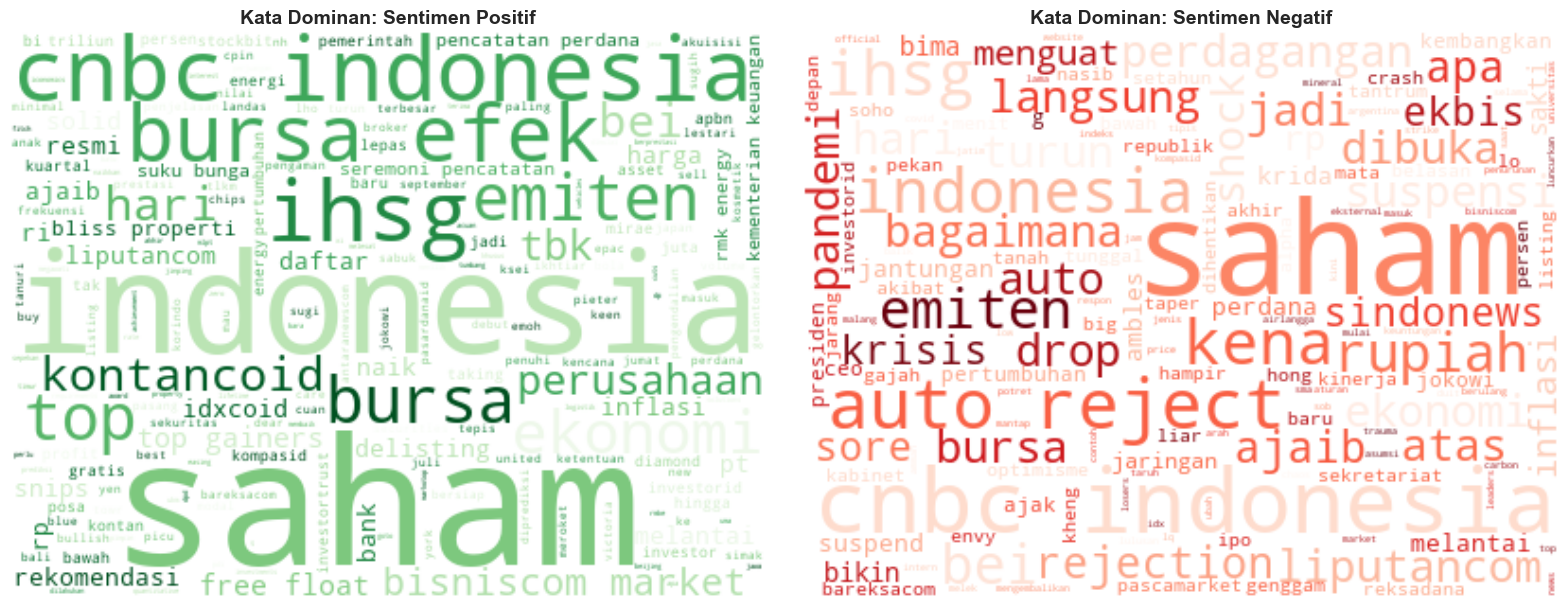

💾 Disimpan: reports/figures/wordcloud_sentiment.png


In [100]:
# ============================================================
# CELL 9: WORD CLOUD
# ============================================================
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load berita yang sudah di-clean
df_news = pd.read_csv(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\data\processed\news_cleaned.csv')

# Pisah berita positif dan negatif berdasarkan VADER
df_news['vader_score'] = df_news['title_clean'].apply(
    lambda x: SentimentIntensityAnalyzer().polarity_scores(str(x))['compound'] if pd.notna(x) else 0
)

positive_text = ' '.join(df_news[df_news['vader_score'] > 0.05]['title_clean'].dropna())
negative_text = ' '.join(df_news[df_news['vader_score'] < -0.05]['title_clean'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive word cloud
if positive_text:
    wc_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(positive_text)
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('Kata Dominan: Sentimen Positif', fontsize=14, fontweight='bold')
    axes[0].axis('off')

# Negative word cloud
if negative_text:
    wc_neg = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(negative_text)
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('Kata Dominan: Sentimen Negatif', fontsize=14, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\ADVAN\Desktop\analisis_sentimen_ihsg\reports\figures\wordcloud_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Disimpan: reports/figures/wordcloud_sentiment.png")